# Multiway Number Partitioning en qutrits: CD-ADAPT-VQE vs QAOA

Repartir $N$ números en $k=3$ partes lo más parejas posible, con un qutrit por elemento ($H_p=\sum_i(\hat\Sigma_i-\mu\hat I)^2$; derivación completa en `formulacion_qubo.tex`, misma carpeta).

**Contenido de este cuadernillo, a grandes rasgos:**
1. **Toy** ($n=5$, partición perfecta conocida) -- primera corrida de CD-ADAPT-VQE ($l=1,2$) y QAOA/CMA-ES, para validar el pipeline y comparar los métodos en detalle.
2. **Batch de 20 instancias** ($n=5,6$): 10 genéricas y 10 con partición perfecta garantizada -- misma comparación con estadística en vez de un solo caso curado, y aísla si la dificultad observada en $n=6$ depende de que el óptimo sea $H_p=0$ o no.

Motor numérico en `utilidades/utilidades_multiway.py`.

## 0. Imports

Motor del proyecto (`utilidades/utilidades_multiway.py`, `funciones/utilidades_QAOA.py`) y librerías estándar.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

THIS_DIR = Path(".").resolve()
if str(THIS_DIR) not in sys.path:
    sys.path.insert(0, str(THIS_DIR))

import time
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

from utilidades.utilidades_multiway import (
    Hp_multiway,
    build_pool_multiway,
    initial_state,
    cd_adapt_vqe_multiway,
    preparar_qaoa_multiway,
    scan_qaoa_p_multiway,
    top_partitions,
    decode_partition,
    imbalance,
)
from funciones.utilidades_QAOA import (
    qaoa_qudit_state_numpy,
    curva_qaoa_con_banda_desde_all_runs,
)

## 1. Instancia toy

$a = \{1,2,3,4,5\}$, $N=5$ elementos, $n=5$ qutrits (uno por elemento). $\mu = \tfrac13\sum_j a_j = 5$.

Existe una particion perfectamente balanceada: $\{5\}$, $\{1,4\}$, $\{2,3\}$, las tres con suma $5=\mu$ -- asi que el minimo exacto $H_p=0$ es alcanzable (no siempre es el caso, ver `formulacion_qubo.tex` S3.4).

In [2]:
a = [1, 2, 3, 4, 5]
n = len(a)
mu = sum(a) / 3

print(f"a = {a}")
print(f"n = {n} qutrits")
print(f"mu = {mu}")
print("Particion balanceada conocida: {5} | {1,4} | {2,3}  (las tres suman 5)")

a = [1, 2, 3, 4, 5]
n = 5 qutrits
mu = 5.0
Particion balanceada conocida: {5} | {1,4} | {2,3}  (las tres suman 5)


### Caché de resultados del toy

Las corridas de las Secciones 3 y 4 (en especial el barrido QAOA, ~14 min) se guardan en `datos/toy_cache/` la primera vez que se ejecutan (`cachear_adapt`/`cachear_qaoa` en `utilidades/utilidades_multiway.py`). Con `RECOMPUTE_TOY=False` se carga directo del caché; `True` fuerza una corrida nueva.

In [ ]:
from utilidades.utilidades_multiway import cachear_adapt, cachear_qaoa

RECOMPUTE_TOY = False  # True para recalcular todo el toy desde cero, ignorando el cache
TOY_CACHE_DIR = Path("datos/toy_cache")

## 2. Hamiltoniano de costo $H_p$

In [4]:
Hf = Hp_multiway(n, a)

evals = Hf.eigenenergies()
E0 = float(evals[0])
degeneracy = int(np.sum(np.abs(evals - E0) < 1e-9))

print(f"Hermitico: {Hf.isherm}")
print(f"Diagonal en base computacional: {np.allclose(Hf.full(), np.diag(np.diag(Hf.full())))}")
print(f"Ground energy: {E0}")
print(f"Degeneracion del ground state: {degeneracy}  (multiplo de 3! = 6 esperado por la simetria de etiquetas)")

Hermitico: True
Diagonal en base computacional: True
Ground energy: 0.0
Degeneracion del ground state: 6  (multiplo de 3! = 6 esperado por la simetria de etiquetas)


## 3. CD-ADAPT-VQE

### 3.1 $l=1$ (solo $O_1$)

Pool construido via `nested_commutators(Had, dHad_dlam, order=1)`, igual patron que Max-3-Cut y factorizacion.

In [5]:
psi0, E0_hi = initial_state(n)

def _correr_l1():
    pool_l1, labels_l1 = build_pool_multiway(n, a, l=1)
    print(f"Pool l=1: {len(pool_l1)} operadores")
    return cd_adapt_vqe_multiway(Hf, psi0, pool_l1, labels_l1, epsilon=1e-3, max_iteration=15, show=True)

res_l1, desde_cache = cachear_adapt(TOY_CACHE_DIR / "adapt_l1.json", RECOMPUTE_TOY, _correr_l1)
print("Cargado desde cache" if desde_cache else "Recalculado", f"-- l=1 ({res_l1['runtime_min']:.2f} min)")

Cargado desde cache -- l=1 (0.14 min)


In [6]:
print("Operadores seleccionados por el ADAPT (l=1), en orden:")
for i, lbl in enumerate(res_l1["ansatz_op_labels"], start=1):
    print(f"  {i}. {lbl}")

print()
print("Energia final:", res_l1["final_energy"], " (ground energy:", res_l1["ground_energy"], ")")
print("Diferencia con el ground state:", res_l1["difference_ground"])

print()
print("Top-5 particiones mas probables al medir el estado final (l=1):")
for cand in top_partitions(res_l1["psi_final"], n, a, top_k=5):
    print(f"  digits={cand['digits']} | sumas={cand['sumas']} | imbalance={cand['imbalance']:.2f} | prob={cand['prob']:.4f}")

Operadores seleccionados por el ADAPT (l=1), en orden:
  1. ((4, 'y'), (5, 'z'))
  2. ((3, 'y'), (3, 'z'), (5, 'z'), (5, 'z'))
  3. ((4, 'z'), (5, 'y'))
  4. ((4, 'y'), (4, 'z'))
  5. ((4, 'z'), (5, 'y'))
  6. ((4, 'z'), (4, 'z'), (5, 'y'), (5, 'z'))
  7. ((4, 'y'), (5, 'z'))
  8. ((2, 'y'), (2, 'z'), (5, 'z'), (5, 'z'))
  9. ((3, 'y'), (3, 'z'))
  10. ((1, 'y'), (5, 'z'))

Energia final: 0.05719095841916661  (ground energy: 0.0 )
Diferencia con el ground state: 0.05719095841916661

Top-5 particiones mas probables al medir el estado final (l=1):
  digits=(2, 1, 1, 2, 0) | sumas=(5.0, 5.0, 5.0) | imbalance=0.00 | prob=0.4857
  digits=(0, 1, 1, 0, 2) | sumas=(5.0, 5.0, 5.0) | imbalance=0.00 | prob=0.4857
  digits=(0, 1, 1, 2, 0) | sumas=(6.0, 5.0, 4.0) | imbalance=2.00 | prob=0.0143
  digits=(2, 1, 1, 0, 2) | sumas=(4.0, 5.0, 6.0) | imbalance=2.00 | prob=0.0143
  digits=(1, 1, 1, 2, 0) | sumas=(5.0, 6.0, 4.0) | imbalance=2.00 | prob=0.0000


### 3.2 $l=2$ ($O_1\cup O_3$)

El pool salta de 50 a 1755 operadores (agrega $O_3$), pero para $n=5$ sigue siendo rapido: ~10s armar el pool, ~30s la corrida ADAPT completa. Es la comparacion $l=1$ vs $l=2$ que ya es estandar en el resto del proyecto para Max-3-Cut y factorizacion.

In [7]:
def _correr_l2():
    pool_l2, labels_l2 = build_pool_multiway(n, a, l=2)
    print(f"Pool l=2: {len(pool_l2)} operadores")
    return cd_adapt_vqe_multiway(Hf, psi0, pool_l2, labels_l2, epsilon=1e-3, max_iteration=15, show=True)

res_l2, desde_cache = cachear_adapt(TOY_CACHE_DIR / "adapt_l2.json", RECOMPUTE_TOY, _correr_l2)
print("Cargado desde cache" if desde_cache else "Recalculado", f"-- l=2 ({res_l2['runtime_min']:.2f} min)")

Cargado desde cache -- l=2 (0.45 min)


In [8]:
print("Operadores seleccionados por el ADAPT (l=2), en orden:")
for i, lbl in enumerate(res_l2["ansatz_op_labels"], start=1):
    print(f"  {i}. {lbl}")

print()
print("Energia final:", res_l2["final_energy"], " (ground energy:", res_l2["ground_energy"], ")")
print("Diferencia con el ground state:", res_l2["difference_ground"])

print()
print("Top-5 particiones mas probables al medir el estado final (l=2):")
for cand in top_partitions(res_l2["psi_final"], n, a, top_k=5):
    print(f"  digits={cand['digits']} | sumas={cand['sumas']} | imbalance={cand['imbalance']:.2f} | prob={cand['prob']:.4f}")

Operadores seleccionados por el ADAPT (l=2), en orden:
  1. ((4, 'y'), (5, 'z'))
  2. ((3, 'y'), (3, 'z'), (5, 'z'), (5, 'z'))
  3. ((4, 'x'), (5, 'y'), (5, 'z'))
  4. ((2, 'x'), (4, 'z'), (5, 'y'))
  5. ((3, 'x'), (4, 'z'), (5, 'y'))
  6. ((3, 'y'), (3, 'z'), (4, 'z'), (4, 'z'), (4, 'z'), (5, 'z'))
  7. ((2, 'y'), (2, 'z'), (4, 'z'), (4, 'z'))
  8. ((4, 'z'), (4, 'z'), (4, 'z'), (5, 'x'), (5, 'y'))
  9. ((1, 'x'), (4, 'z'), (5, 'y'))
  10. ((1, 'z'), (1, 'z'), (4, 'z'), (5, 'y'))
  11. ((3, 'y'), (3, 'z'), (5, 'y'), (5, 'y'))
  12. ((1, 'y'), (4, 'z'), (5, 'z'), (5, 'z'))
  13. ((1, 'x'), (1, 'y'), (4, 'z'), (5, 'z'), (5, 'z'))
  14. ((4, 'x'), (4, 'y'), (5, 'z'), (5, 'z'), (5, 'z'))

Energia final: 7.584555071612306e-13  (ground energy: 0.0 )
Diferencia con el ground state: 7.584555071612306e-13

Top-5 particiones mas probables al medir el estado final (l=2):
  digits=(0, 1, 1, 0, 2) | sumas=(5.0, 5.0, 5.0) | imbalance=0.00 | prob=0.5000
  digits=(2, 1, 1, 2, 0) | sumas=(5.0, 5.0, 5.

## 4. QAOA

Barrido en profundidad $p=1,\dots,10$ ($2p=20$ parámetros máx., mismo rango que CD-ADAPT-VQE), optimizado con **CMA-ES** (25 reinicios por profundidad, sin warm-start) en vez de L-BFGS-B.

In [9]:
qaoa_results, desde_cache = cachear_qaoa(
    TOY_CACHE_DIR / "qaoa_scan.json", RECOMPUTE_TOY,
    lambda: scan_qaoa_p_multiway(
        n, Hf, p_max=10, mixer="jx", method="CMA-ES",
        num_restarts=25, maxiter=500, seed=7, use_warmstart=False, show=False,
    ),
)
print("Cargado desde cache" if desde_cache else "Recalculado", "-- QAOA/CMA-ES (p=1..10)\n")

for r in qaoa_results:
    print(f"p={r['p']} | num_params={r['num_params']} | best_energy={r['best_energy']:.6f} | "
          f"abs_error={r['absolute_error']:.6e} | runtime_min={r['runtime_min']:.4f}")

Cargado desde cache -- QAOA/CMA-ES (p=1..10)

p=1 | num_params=2 | best_energy=19.467523 | abs_error=1.946752e+01 | runtime_min=0.4505
p=2 | num_params=4 | best_energy=19.600340 | abs_error=1.960034e+01 | runtime_min=0.5920
p=3 | num_params=6 | best_energy=21.276060 | abs_error=2.127606e+01 | runtime_min=0.8146
p=4 | num_params=8 | best_energy=18.902289 | abs_error=1.890229e+01 | runtime_min=1.0129
p=5 | num_params=10 | best_energy=21.444695 | abs_error=2.144469e+01 | runtime_min=1.2428
p=6 | num_params=12 | best_energy=24.183033 | abs_error=2.418303e+01 | runtime_min=1.4821
p=7 | num_params=14 | best_energy=26.231593 | abs_error=2.623159e+01 | runtime_min=1.6918
p=8 | num_params=16 | best_energy=26.722476 | abs_error=2.672248e+01 | runtime_min=1.9602
p=9 | num_params=18 | best_energy=28.252595 | abs_error=2.825260e+01 | runtime_min=2.2090
p=10 | num_params=20 | best_energy=26.822524 | abs_error=2.682252e+01 | runtime_min=2.4264


In [10]:
# Decodificar la particion mas probable del mejor QAOA (p mas profundo)
qaoa_data = preparar_qaoa_multiway(n, Hf, mixer="jx")
best = qaoa_results[-1]
p_best = best["p"]

psi_qaoa_vec = qaoa_qudit_state_numpy(
    best["best_params"], qaoa_data["spec_Hc"], qaoa_data["spec_Hm"], qaoa_data["psi0_vec"], p_best
)
psi_qaoa = qt.Qobj(psi_qaoa_vec.reshape(-1, 1), dims=[[3] * n, [1] * n])

print(f"Top-5 particiones mas probables, QAOA p={p_best}:")
for cand in top_partitions(psi_qaoa, n, a, top_k=5):
    print(f"  digits={cand['digits']} | sumas={cand['sumas']} | imbalance={cand['imbalance']:.2f} | prob={cand['prob']:.4f}")

Top-5 particiones mas probables, QAOA p=10:
  digits=(1, 2, 0, 0, 2) | sumas=(7.0, 1.0, 7.0) | imbalance=6.00 | prob=0.0226
  digits=(1, 0, 2, 2, 0) | sumas=(7.0, 1.0, 7.0) | imbalance=6.00 | prob=0.0226
  digits=(1, 2, 2, 1, 0) | sumas=(5.0, 5.0, 5.0) | imbalance=0.00 | prob=0.0215
  digits=(1, 0, 0, 1, 2) | sumas=(5.0, 5.0, 5.0) | imbalance=0.00 | prob=0.0215
  digits=(2, 2, 1, 0, 2) | sumas=(4.0, 3.0, 8.0) | imbalance=5.00 | prob=0.0179


## 5. Comparación

Error absoluto $|E-E_0|$ vs. número de parámetros variacionales, mismo criterio que `cuadernillos/comparacion_QAOA.ipynb` para Max-3-Cut (acá $E_0=0$, así que no aplica error relativo). Para QAOA se muestra la mediana y la banda RIC (Q25-Q75) de los 25 restarts de CMA-ES por profundidad, además del mejor restart.

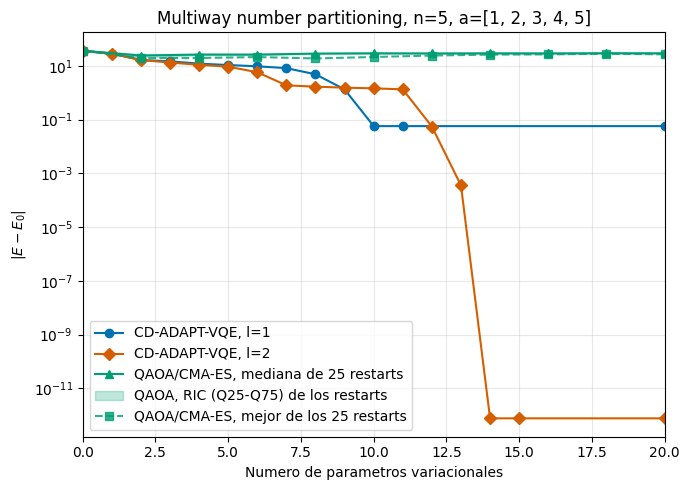

In [11]:
X_MAX = 20


def extender_plano(x, y, x_max):
    """Repite el ultimo valor hasta x_max: una vez que el ADAPT converge,
    agregar mas parametros no cambia el error."""
    x, y = list(x), list(y)
    if x[-1] < x_max:
        x.append(x_max)
        y.append(y[-1])
    return np.array(x), np.array(y)


adapt_error_l1 = [abs(e - res_l1["ground_energy"]) for e in res_l1["energy_trace"]]
adapt_x_l1 = list(range(len(adapt_error_l1)))
adapt_x_l1, adapt_error_l1 = extender_plano(adapt_x_l1, adapt_error_l1, X_MAX)

adapt_error_l2 = [abs(e - res_l2["ground_energy"]) for e in res_l2["energy_trace"]]
adapt_x_l2 = list(range(len(adapt_error_l2)))
adapt_x_l2, adapt_error_l2 = extender_plano(adapt_x_l2, adapt_error_l2, X_MAX)

qaoa_x, qaoa_median, qaoa_low, qaoa_high, qaoa_best = curva_qaoa_con_banda_desde_all_runs(
    qaoa_results, band_type="iqr", incluir_warmstart=False,
)

# mismo psi_0 para los tres metodos -> mismo error inicial en x=0
error_inicial = abs(qaoa_data["initial_problem_energy"] - res_l1["ground_energy"])
qaoa_x = np.concatenate([[0], qaoa_x])
qaoa_median = np.concatenate([[error_inicial], qaoa_median])
qaoa_low = np.concatenate([[error_inicial], qaoa_low])
qaoa_high = np.concatenate([[error_inicial], qaoa_high])
qaoa_best = np.concatenate([[error_inicial], qaoa_best])

C1 = "#0072B2"
C2 = "#D55E00"
C3 = "#009E73"

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(adapt_x_l1, np.maximum(adapt_error_l1, 1e-16), marker="o", color=C1,
        label="CD-ADAPT-VQE, l=1")

ax.plot(adapt_x_l2, np.maximum(adapt_error_l2, 1e-16), marker="D", color=C2,
        label="CD-ADAPT-VQE, l=2")

ax.plot(qaoa_x, np.maximum(qaoa_median, 1e-16), marker="^", color=C3,
        label="QAOA/CMA-ES, mediana de 25 restarts")

ax.fill_between(qaoa_x, np.maximum(qaoa_low, 1e-16), np.maximum(qaoa_high, 1e-16),
                 alpha=0.25, color=C3, label="QAOA, RIC (Q25-Q75) de los restarts")

ax.plot(qaoa_x, np.maximum(qaoa_best, 1e-16), marker="s", linestyle="--", color=C3,
        alpha=0.8, label="QAOA/CMA-ES, mejor de los 25 restarts")

ax.set_xlim(0, X_MAX)
ax.set_yscale("log")
ax.set_xlabel("Numero de parametros variacionales")
ax.set_ylabel(r"$|E - E_0|$")
ax.set_title(f"Multiway number partitioning, n={n}, a={a}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparacion_toy.png", dpi=150)
plt.show()

## 6. Más allá del toy: 10 instancias genéricas y 10 balanceadas ($n=5,6$)

### 6.1 Las instancias

**Genérica**: elementos uniformes en $[1,15]$, sin garantía de que exista partición perfecta. **Balanceada**: construida para que sí exista partición perfecta ($H_p=0$), garantizado por construcción.

Guardadas en `datos/casos_n{5,6}.txt` (genéricas) y `datos/casos_n{5,6}_balanceados.txt` (balanceadas), una instancia por línea.

**$n=5$**

| tipo | a | suma | mu |
|---|---|---|---|
| genérica | [11, 2, 1, 12, 5] | 31 | 10.33 |
| genérica | [4, 4, 3, 12, 2] | 25 | 8.33 |
| genérica | [11, 12, 15, 9, 2] | 49 | 16.33 |
| genérica | [10, 7, 1, 1, 2] | 21 | 7 |
| genérica | [4, 4, 9, 10, 1] | 28 | 9.33 |
| balanceada | [1, 2, 1, 1, 1] | 6 | 2 |
| balanceada | [13, 2, 11, 12, 1] | 39 | 13 |
| balanceada | [14, 13, 1, 13, 1] | 42 | 14 |
| balanceada | [7, 2, 15, 15, 6] | 45 | 15 |
| balanceada | [4, 1, 5, 6, 2] | 18 | 6 |

**$n=6$**

| tipo | a | suma | mu |
|---|---|---|---|
| genérica | [1, 5, 12, 13, 3, 8] | 42 | 14 |
| genérica | [6, 11, 12, 13, 2, 8] | 52 | 17.33 |
| genérica | [10, 8, 10, 1, 9, 7] | 45 | 15 |
| genérica | [10, 6, 10, 14, 9, 15] | 64 | 21.33 |
| genérica | [13, 7, 7, 3, 1, 14] | 45 | 15 |
| balanceada | [14, 10, 5, 4, 5, 4] | 42 | 14 |
| balanceada | [4, 2, 3, 1, 6, 5] | 21 | 7 |
| balanceada | [3, 1, 4, 2, 2, 6] | 18 | 6 |
| balanceada | [5, 15, 9, 13, 3, 9] | 54 | 18 |
| balanceada | [8, 4, 6, 2, 1, 3] | 24 | 8 |

Desempeño de los tres métodos por instancia (error absoluto $|E-E_0|$):

In [12]:
import pandas as pd


def cargar_df_adapt(tipo, sufijo):
    dfs = []
    for l in (1, 2):
        for n_tag in ("n5", "n6"):
            df_l = pd.read_csv(f"resultados/csv/resultados_multiway_l{l}_{n_tag}{sufijo}_5casos.csv")
            df_l.insert(0, "instancia_idx", range(1, len(df_l) + 1))
            df_l.insert(0, "tipo", tipo)
            dfs.append(df_l)
    return pd.concat(dfs, ignore_index=True)


df_adapt = cargar_df_adapt("genérica", "")
df_adapt_bal = cargar_df_adapt("balanceada", "_balanceados")
df_adapt_all = pd.concat([df_adapt, df_adapt_bal], ignore_index=True)


def cargar_df_qaoa(tipo, n_tag, sufijo):
    if sufijo:
        df = pd.concat(
            [pd.read_csv(f"resultados/csv/resultados_multiway_qaoa_{n_tag}_p10_jx_CMA-ES_r25{sufijo}_casos_{i}_{i}.csv")
             for i in range(1, 6)],
            ignore_index=True,
        )
    else:
        df = pd.read_csv(f"resultados/csv/resultados_multiway_qaoa_{n_tag}_p10_jx_CMA-ES_r25_5casos.csv")
    df.insert(0, "tipo", tipo)
    return df


dfs_qaoa = []
for n_tag in ("n5", "n6"):
    dfs_qaoa.append(cargar_df_qaoa("genérica", n_tag, ""))
    dfs_qaoa.append(cargar_df_qaoa("balanceada", n_tag, "_balanceados"))
df_qaoa = pd.concat(dfs_qaoa, ignore_index=True)

df_l1 = df_adapt_all[df_adapt_all.l == 1][
    ["tipo", "n", "instancia_idx", "a", "difference_ground", "num_ansatz_ops"]
].rename(columns={"difference_ground": "error_l1", "num_ansatz_ops": "params_l1"})
df_l2 = df_adapt_all[df_adapt_all.l == 2][
    ["tipo", "n", "instancia_idx", "difference_ground", "num_ansatz_ops"]
].rename(columns={"difference_ground": "error_l2", "num_ansatz_ops": "params_l2"})
df_qaoa_err = df_qaoa[df_qaoa.p == 10][
    ["tipo", "n", "instancia_idx", "absolute_error", "num_params"]
].rename(columns={"absolute_error": "error_qaoa", "num_params": "params_qaoa"})

tabla_instancias = (
    df_l1.merge(df_l2, on=["tipo", "n", "instancia_idx"])
         .merge(df_qaoa_err, on=["tipo", "n", "instancia_idx"], how="left")
)
cols_orden = ["tipo", "n", "a",
              "params_l1", "error_l1", "params_l2", "error_l2", "params_qaoa", "error_qaoa"]
tabla_instancias.sort_values(["tipo", "n", "instancia_idx"])[cols_orden].reset_index(drop=True)

,tipo,n,a,params_l1,error_l1,params_l2,error_l2,params_qaoa,error_qaoa
0,balanceada,5,"[1, 2, 1, 1, 1]",10,0.333333,19,4.353599e-11,20,3.833947
1,balanceada,5,"[13, 2, 11, 12, 1]",10,0.057191,11,7.360046e-14,20,218.645876
2,balanceada,5,"[14, 13, 1, 13, 1]",15,0.057191,15,7.829783e-13,20,228.385483
3,balanceada,5,"[7, 2, 15, 15, 6]",30,1.985701,14,3.930146e-12,20,316.761102
4,balanceada,5,"[4, 1, 5, 6, 2]",10,2.114382,12,1.138792e-11,20,41.867245
5,balanceada,6,"[14, 10, 5, 4, 5, 4]",13,6.387847,15,9.874105e-14,20,210.375812
6,balanceada,6,"[4, 2, 3, 1, 6, 5]",11,2.232035,18,3.917617e-02,20,50.539114
7,balanceada,6,"[3, 1, 4, 2, 2, 6]",20,1.251804,13,2.712124e-11,20,38.115182
8,balanceada,6,"[5, 15, 9, 13, 3, 9]",11,4.857864,14,4.000000e+00,20,346.275777
9,balanceada,6,"[8, 4, 6, 2, 1, 3]",30,2.345427,18,1.473257e-12,20,72.956612


### 6.2 Análisis general

Gráfico con las 20 instancias juntas por $n$ (sin separar por tipo todavía), con los tres métodos: mediana + banda RIC (Q25-Q75) del error relativo $|E-E_0|/|E_0|$ vs. número de parámetros -- mismo criterio que la Sección 5. Los tres métodos agregan las 10 instancias de cada $n$ (5 genéricas + 5 balanceadas juntas).

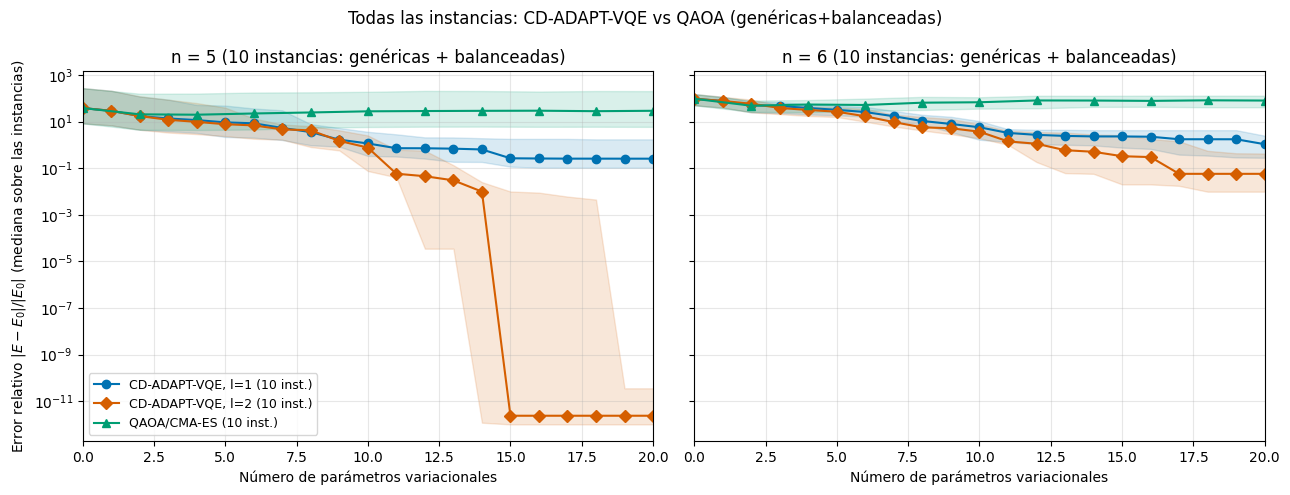

In [13]:
import json


def cargar_traces_adapt(l, n_tag, sufijo=""):
    with open(f"resultados/json/resultados_multiway_l{l}_{n_tag}{sufijo}_5casos.json", encoding="utf-8") as f:
        data = json.load(f)
    traces = []
    for item in data:
        ge = item["ground_energy"]
        et = np.array(item["energy_trace"], dtype=float)
        rel = np.abs(et - ge) if abs(ge) < 1e-12 else np.abs(et - ge) / abs(ge)
        traces.append(rel)
    return traces


def agregar_mediana_iqr(traces, x_max):
    """Extiende cada traza (relleno plano tras convergencia) hasta x_max y calcula
    mediana + IQR punto a punto sobre las instancias."""
    padded = []
    for tr in traces:
        if len(tr) - 1 < x_max:
            tr = np.concatenate([tr, np.full(x_max - (len(tr) - 1), tr[-1])])
        else:
            tr = tr[: x_max + 1]
        padded.append(tr)
    M = np.array(padded)
    x = np.arange(x_max + 1)
    return x, np.median(M, axis=0), np.percentile(M, 25, axis=0), np.percentile(M, 75, axis=0)


def agregar_qaoa(df_qaoa_n, x_max):
    """Mediana + IQR del relative_error sobre las instancias, para cada p; agrega el
    punto x=0 (estado inicial, antes de aplicar QAOA)."""
    x = np.array(sorted(df_qaoa_n["num_params"].unique()))
    g = df_qaoa_n.groupby("num_params")["relative_error"]
    med = np.array([g.get_group(xi).median() for xi in x])
    q25 = np.array([g.get_group(xi).quantile(0.25) for xi in x])
    q75 = np.array([g.get_group(xi).quantile(0.75) for xi in x])

    inicial = df_qaoa_n.drop_duplicates(["tipo", "instancia_idx"])
    ge = inicial["ground_energy"].abs()
    diff = (inicial["initial_problem_energy"] - inicial["ground_energy"]).abs()
    err0 = pd.Series(np.where(ge < 1e-12, diff, diff / ge))
    x = np.concatenate([[0], x[x <= x_max]])
    med = np.concatenate([[err0.median()], med[: len(x) - 1]])
    q25 = np.concatenate([[err0.quantile(0.25)], q25[: len(x) - 1]])
    q75 = np.concatenate([[err0.quantile(0.75)], q75[: len(x) - 1]])
    return x, med, q25, q75


X_MAX = 20
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, n_tag, n_val in zip(axes, ("n5", "n6"), (5, 6)):
    traces_l1 = cargar_traces_adapt(1, n_tag) + cargar_traces_adapt(1, n_tag, "_balanceados")
    traces_l2 = cargar_traces_adapt(2, n_tag) + cargar_traces_adapt(2, n_tag, "_balanceados")
    x1, med1, q25_1, q75_1 = agregar_mediana_iqr(traces_l1, X_MAX)
    x2, med2, q25_2, q75_2 = agregar_mediana_iqr(traces_l2, X_MAX)
    xq, medq, q25q, q75q = agregar_qaoa(df_qaoa[df_qaoa.n == n_val], X_MAX)

    ax.plot(x1, np.maximum(med1, 1e-12), marker="o", color=C1, label="CD-ADAPT-VQE, l=1 (10 inst.)")
    ax.fill_between(x1, np.maximum(q25_1, 1e-12), np.maximum(q75_1, 1e-12), alpha=0.15, color=C1)

    ax.plot(x2, np.maximum(med2, 1e-12), marker="D", color=C2, label="CD-ADAPT-VQE, l=2 (10 inst.)")
    ax.fill_between(x2, np.maximum(q25_2, 1e-12), np.maximum(q75_2, 1e-12), alpha=0.15, color=C2)

    ax.plot(xq, np.maximum(medq, 1e-12), marker="^", color=C3, label="QAOA/CMA-ES (10 inst.)")
    ax.fill_between(xq, np.maximum(q25q, 1e-12), np.maximum(q75q, 1e-12), alpha=0.15, color=C3)

    ax.set_yscale("log")
    ax.set_xlim(0, X_MAX)
    ax.set_xlabel("Número de parámetros variacionales")
    ax.set_title(f"n = {n_val} (10 instancias: genéricas + balanceadas)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel(r"Error relativo $|E-E_0|/|E_0|$ (mediana sobre las instancias)")
axes[0].legend(fontsize=9)
plt.suptitle("Todas las instancias: CD-ADAPT-VQE vs QAOA (genéricas+balanceadas)")
plt.tight_layout()
plt.savefig("comparacion_batch_todas.png", dpi=150)
plt.show()

**Observación:** con las 10 instancias juntas por $n$, se confirma la misma tendencia del toy (Sección 5): CD-ADAPT-VQE $l=2$ domina ampliamente a QAOA en ambos $n$, y la brecha entre $l=1$ y $l=2$ se agranda en $n=6$. La sección siguiente separa por tipo (genérica/balanceada) para entender por qué $n=6$ sigue sin resolverse del todo incluso con $l=2$.

### 6.3 CD-ADAPT-VQE: genéricas vs. balanceadas

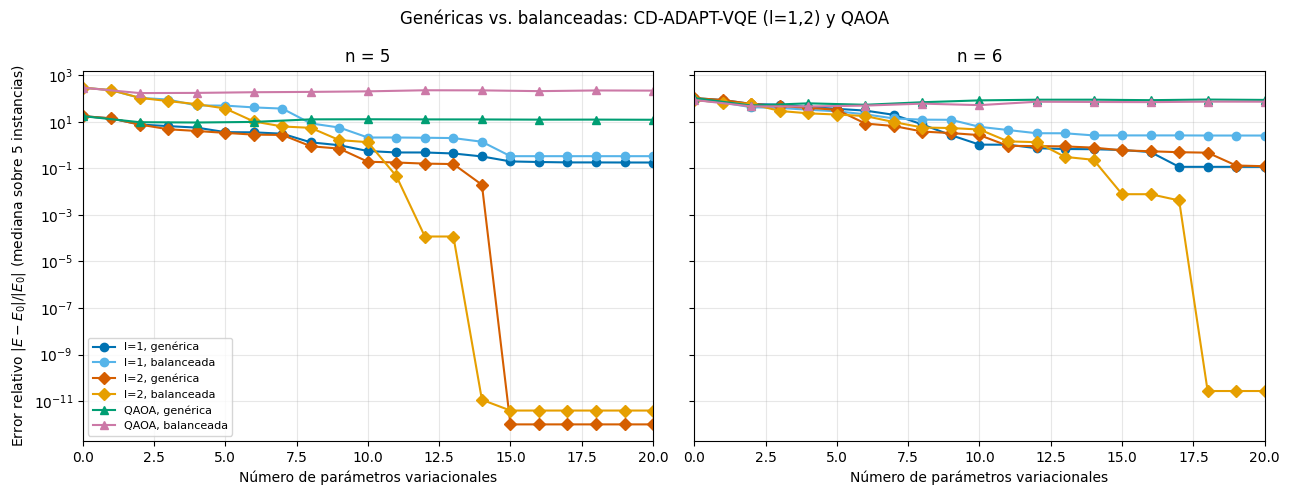

In [14]:
C4 = "#56B4E9"  # celeste -- l=1, balanceada
C5 = "#E69F00"  # amarillo/naranja -- l=2, balanceada
C6 = "#CC79A7"  # purpura -- QAOA, balanceada

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, n_tag, n_val in zip(axes, ("n5", "n6"), (5, 6)):
    x1g, med1g, _, _ = agregar_mediana_iqr(cargar_traces_adapt(1, n_tag), X_MAX)
    x1b, med1b, _, _ = agregar_mediana_iqr(cargar_traces_adapt(1, n_tag, "_balanceados"), X_MAX)
    x2g, med2g, _, _ = agregar_mediana_iqr(cargar_traces_adapt(2, n_tag), X_MAX)
    x2b, med2b, _, _ = agregar_mediana_iqr(cargar_traces_adapt(2, n_tag, "_balanceados"), X_MAX)
    xqg, medqg, _, _ = agregar_qaoa(df_qaoa[(df_qaoa.n == n_val) & (df_qaoa.tipo == "genérica")], X_MAX)
    xqb, medqb, _, _ = agregar_qaoa(df_qaoa[(df_qaoa.n == n_val) & (df_qaoa.tipo == "balanceada")], X_MAX)

    ax.plot(x1g, np.maximum(med1g, 1e-12), color=C1, marker="o", label="l=1, genérica")
    ax.plot(x1b, np.maximum(med1b, 1e-12), color=C4, marker="o", label="l=1, balanceada")
    ax.plot(x2g, np.maximum(med2g, 1e-12), color=C2, marker="D", label="l=2, genérica")
    ax.plot(x2b, np.maximum(med2b, 1e-12), color=C5, marker="D", label="l=2, balanceada")
    ax.plot(xqg, np.maximum(medqg, 1e-12), color=C3, marker="^", label="QAOA, genérica")
    ax.plot(xqb, np.maximum(medqb, 1e-12), color=C6, marker="^", label="QAOA, balanceada")

    ax.set_yscale("log")
    ax.set_xlim(0, X_MAX)
    ax.set_xlabel("Número de parámetros variacionales")
    ax.set_title(f"n = {n_val}")
    ax.grid(alpha=0.3)

axes[0].set_ylabel(r"Error relativo $|E-E_0|/|E_0|$ (mediana sobre 5 instancias)")
axes[0].legend(fontsize=8)
plt.suptitle("Genéricas vs. balanceadas: CD-ADAPT-VQE (l=1,2) y QAOA")
plt.tight_layout()
plt.savefig("comparacion_batch_tipo.png", dpi=150)
plt.show()

**Observaciones:**

- **Ninguna de las 10 genéricas tiene partición perfecta** ($\text{ground\_energy}>0$ siempre); las balanceadas sí, por construcción. `found_solution=True` en las genéricas significa "encontró el verdadero óptimo" (el mejor balance posible), no "balance perfecto".
- **$l=1$ no encuentra el óptimo exacto en ninguna instancia**, sea genérica o balanceada (0/10 en ambas).
- **$l=2$ resuelve $n=5$ siempre** (10/10, genérica o balanceada por igual). En $n=6$ depende del tipo: **0/5 en genéricas, pero 3/5 en balanceadas**. Sugiere que la dificultad de $n=6$ no es solo "más qutrits, pool más grande": afinar la energía hasta un valor no trivial (genéricas) parece más difícil para el ADAPT que aterrizar exactamente en $H_p=0$ (balanceadas) -- aunque tampoco es 100% ahí (2/5 balanceadas de $n=6$ siguen sin resolver exacto). Dos de las cinco corridas de $l=2$ en $n=6$ genérica llegan al tope `num_ansatz_ops=30` sin converger por gradiente, así que `max_iteration=30` también puede estar quedándose corto.
- $l=2$ **no domina siempre** a $l=1$ instancia por instancia: en la instancia 4 de $n=6$ genérica ($a=[10,6,10,14,9,15]$), $l=1$ termina con `best_imbalance=4.0` y $l=2$ con `best_imbalance=5.0` -- el ADAPT es *greedy*, sin garantía de monotonicidad estricta caso a caso (sí en promedio).
- **QAOA no se beneficia de que exista partición perfecta**: a diferencia de $l=2$, la curva de QAOA en balanceadas queda tan lejos del óptimo como en genéricas (incluso algo peor). El cuello de botella de QAOA parece ser el paisaje de optimización en sí (landscape multimodal, ver Sección 4), no la dificultad intrínseca de la instancia.